In [1]:
from src.measure_ir import *

import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS


In [2]:
fs = 48000
ad = AudioDevice(fs)

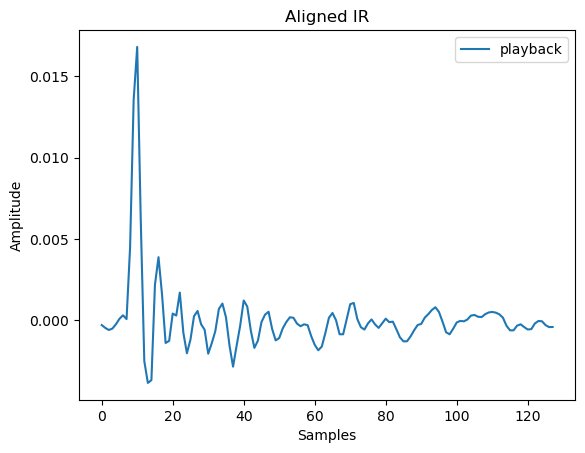

In [3]:
ir_len = 128
panel_to_err_cm = 7

error_ir, _ = measure_ir(ad)
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IR')
plt.legend()
plt.show()

In [4]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')

In [5]:
# arthur_repeated = np.tile(arthur, 20)
# rt = RealtimeFxLMS(ad, source=arthur_repeated, ir=panel_ir, block_size=64)

In [6]:
rt = RealtimeFxLMS(ad, source=arthur, ir=panel_ir, block_size=64)

delays = range(0, 257, 8)
c_gains = [0.1, 0.15, 0.2, 0.25]
signs = [1.0, -1.0]
lags = [lambda rt: rt.full_lag, lambda rt: rt.system_lag, lambda _: 0]

for lag_fn in lags:
    lag = lag_fn(rt)
    for d in delays:
        for c_gain in c_gains:
            for sign in signs:
                rt.reset(lag=lag, filter_order=512)
                rt.w[d] = sign

                error, cancel, *_ = rt.run(
                    cancel_gain=c_gain,
                    fx=False,
                    nlms=False,
                    clean_source=True,
                    step_fn=0,
                    leak=0,
                    max_norm=0.0,
                )

                print('lag:', lag, 'd:', d, 'c_gain:', c_gain, 'sign:', sign, 'db_redux:', rt.db_reduction)

Lag from cross-correlation: 518
Delay from device: 376
lag: 518 d: 0 c_gain: 0.1 sign: 1.0 db_redux: 0.7881209
lag: 518 d: 0 c_gain: 0.1 sign: -1.0 db_redux: -0.070772976
lag: 518 d: 0 c_gain: 0.15 sign: 1.0 db_redux: 1.3508866
lag: 518 d: 0 c_gain: 0.15 sign: -1.0 db_redux: 0.17786472
lag: 518 d: 0 c_gain: 0.2 sign: 1.0 db_redux: 2.0355186
lag: 518 d: 0 c_gain: 0.2 sign: -1.0 db_redux: 0.63809454
lag: 518 d: 0 c_gain: 0.25 sign: 1.0 db_redux: 2.7167373
lag: 518 d: 0 c_gain: 0.25 sign: -1.0 db_redux: 1.2696992
lag: 518 d: 8 c_gain: 0.1 sign: 1.0 db_redux: 0.6482849
lag: 518 d: 8 c_gain: 0.1 sign: -1.0 db_redux: -0.07884249
lag: 518 d: 8 c_gain: 0.15 sign: 1.0 db_redux: 1.2636361
lag: 518 d: 8 c_gain: 0.15 sign: -1.0 db_redux: 0.25544736
lag: 518 d: 8 c_gain: 0.2 sign: 1.0 db_redux: 1.9310346
lag: 518 d: 8 c_gain: 0.2 sign: -1.0 db_redux: 0.7872707
lag: 518 d: 8 c_gain: 0.25 sign: 1.0 db_redux: 2.6370206
lag: 518 d: 8 c_gain: 0.25 sign: -1.0 db_redux: 1.3527033
lag: 518 d: 16 c_gain: 0.

In [7]:
arthur_repeated = np.tile(arthur, 20)
rt = RealtimeFxLMS(ad, source=arthur_repeated, ir=panel_ir, block_size=64)

Lag from cross-correlation: 518
Delay from device: 376


db_redux: -3.741894


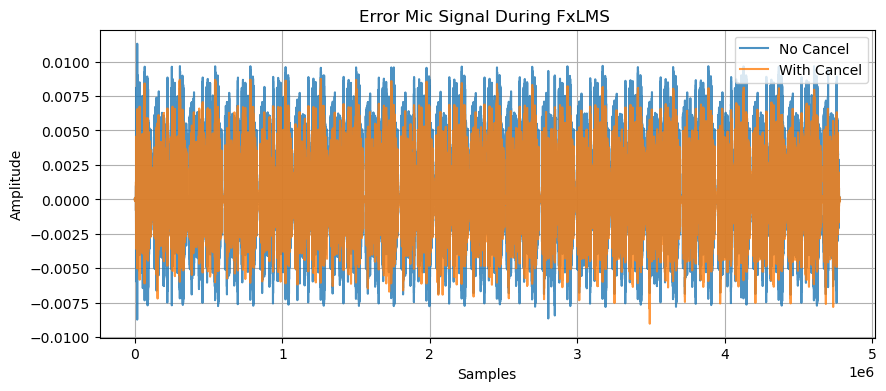

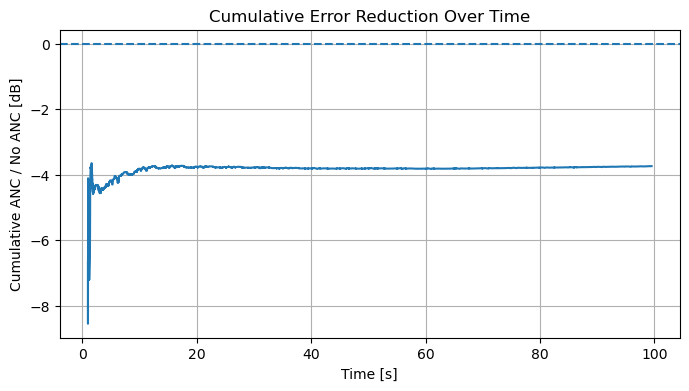

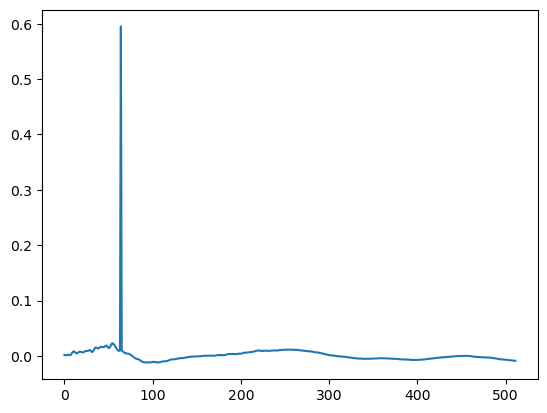

In [13]:
rt.reset(lag=518, filter_order=512)
rt.w[:] = 0
rt.w[64] = 1.0

step_fn = lambda t: 1e-4 / np.sqrt(1 + t / 2000)

error, cancel, *_ = rt.run(
    cancel_gain=0.2,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)

db_redux: -6.749444


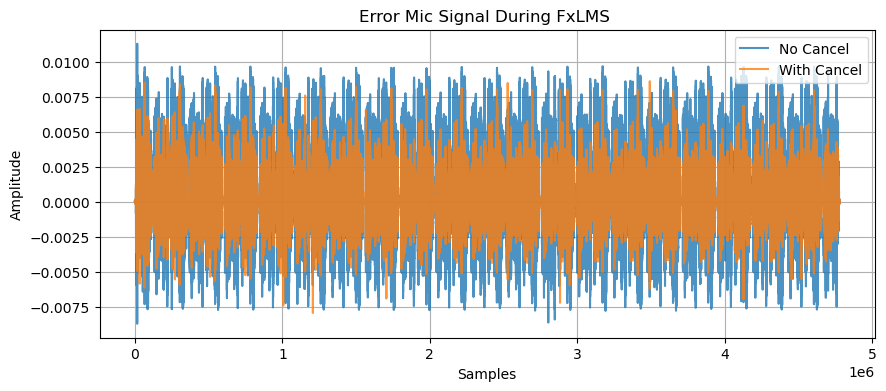

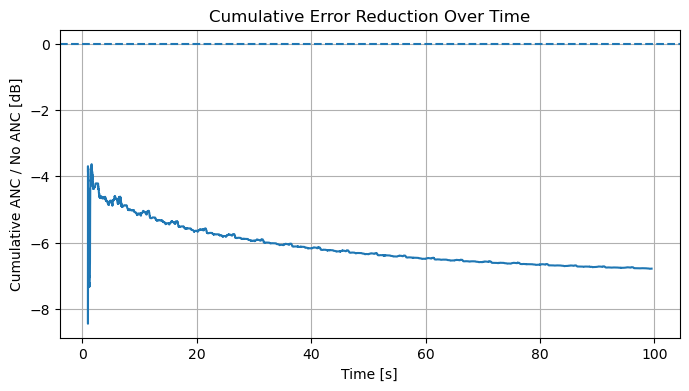

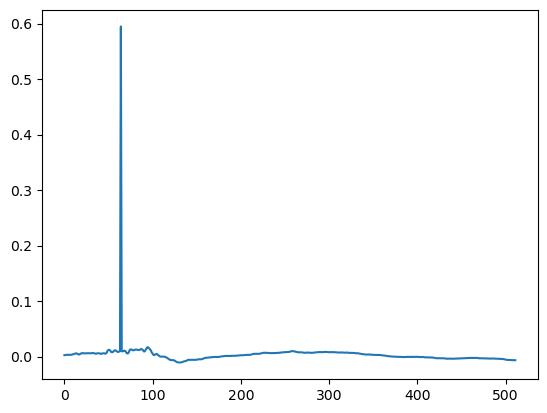

In [11]:
rt.reset(lag=376, filter_order=512)
rt.w[:] = 0
rt.w[64] = 1.0

step_fn = lambda t: 1e-4 / np.sqrt(1 + t / 2000)

error, cancel, *_ = rt.run(
    cancel_gain=0.2,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)

db_redux: 6.96443


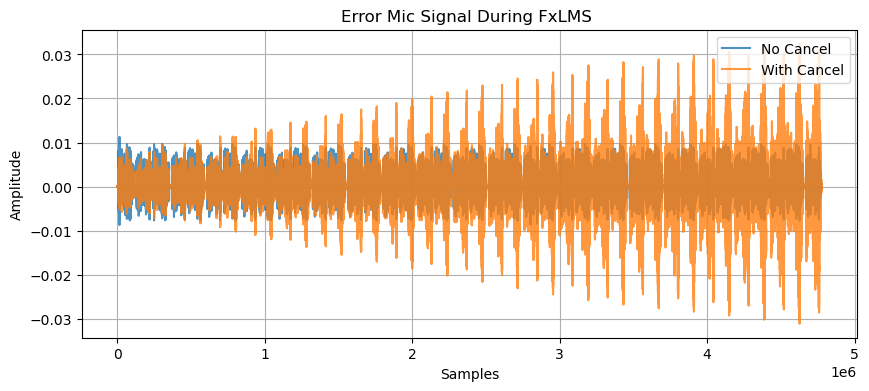

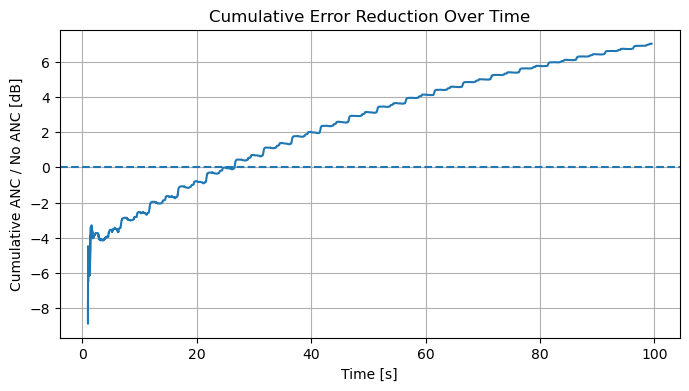

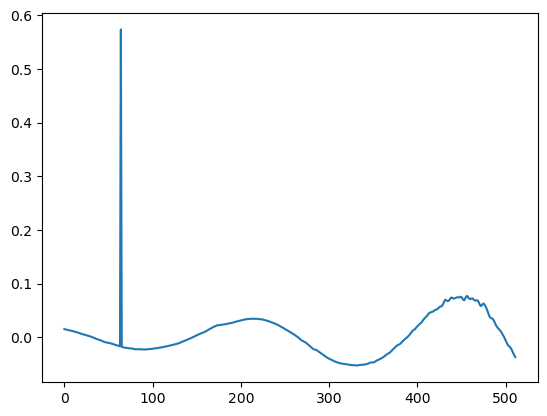

In [14]:
rt.reset(lag=0, filter_order=512)
rt.w[:] = 0
rt.w[64] = 1.0

step_fn = lambda t: 1e-4 / np.sqrt(1 + t / 2000)

error, cancel, *_ = rt.run(
    cancel_gain=0.2,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)

In [15]:
arthur_repeated = np.tile(arthur, 50)
rt = RealtimeFxLMS(ad, source=arthur_repeated, ir=panel_ir, block_size=64)

Lag from cross-correlation: 513
Delay from device: 376


db_redux: -5.5564556


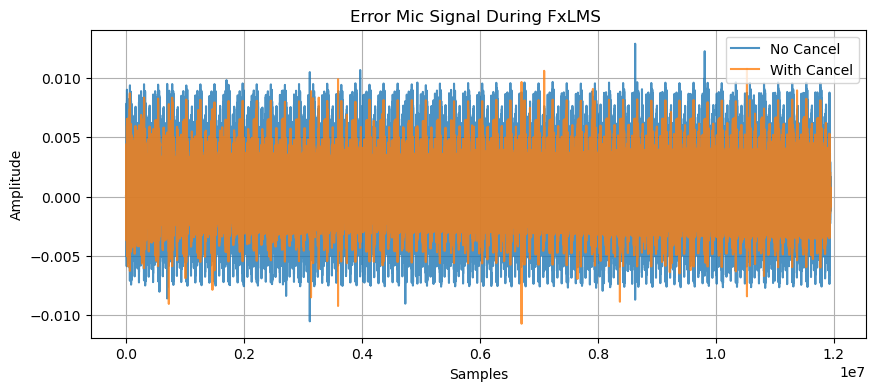

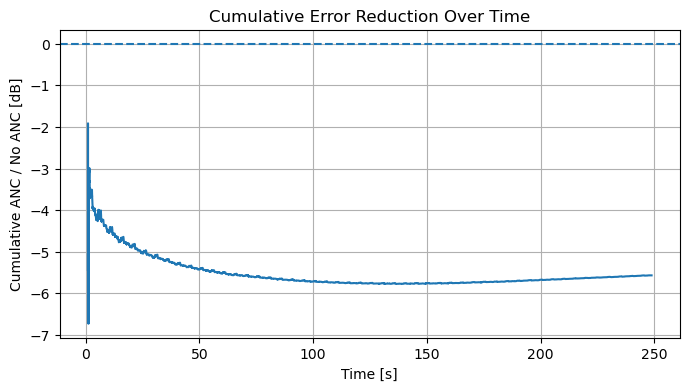

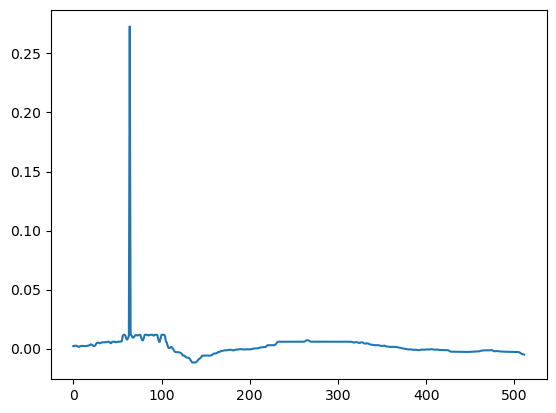

In [20]:
rt.reset(lag=376, filter_order=512)
rt.w[:] = 0
rt.w[64] = 1.0

step_fn = lambda t: 1e-4 / np.sqrt(1 + t / 1000)

error, cancel, *_ = rt.run(
    cancel_gain=0.2,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)

In [24]:
arthur_repeated = np.tile(arthur, 20)
rt = RealtimeFxLMS(ad, source=arthur_repeated, ir=panel_ir, block_size=64)

Lag from cross-correlation: 512
Delay from device: 376


In [25]:
rt.reset(lag=376, filter_order=512)

step_fn = lambda t: 1e-4 / np.sqrt(1 + t / 2000)

error, cancel, *_ = rt.run(
    cancel_gain=0.2,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)

KeyboardInterrupt: 